In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import pandas as pd
import matplotlib.pyplot as plt

from datetime import datetime

from src.risk.IRRBB_shocks import IRRBBShock
from src.risk.eve_engine import EVEEngine

from src.curves.discount_curve import DiscountCurve

In [2]:
# load portfolio cashflows
portfolio_cf = pd.read_csv('../data/processed/portfolio_cashflows.csv', index_col = 0)

# computing time-to-maturity
valuation_date = datetime(2026, 3, 1)
portfolio_cf['date'] = pd.to_datetime(portfolio_cf['date']) 

portfolio_cf['ttm'] = (portfolio_cf['date'] - valuation_date).dt.days / 365.25
portfolio_cf = portfolio_cf.loc[
    portfolio_cf['ttm'] > 0
].reset_index(drop=True)
display(portfolio_cf)


,date,principal,interest,total_cashflow,outstanding_balance,instrument_type,ttm
0,2026-04-01,753.597923,1172.059923,1925.657847,2.984957e+05,asset,0.084873
1,2026-05-01,756.549515,1169.108332,1925.657847,2.977392e+05,asset,0.167009
2,2026-06-01,759.512668,1166.145179,1925.657847,2.969797e+05,asset,0.251882
3,2026-07-01,762.487426,1163.170421,1925.657847,2.962172e+05,asset,0.334018
4,2026-08-01,765.473835,1160.184012,1925.657847,2.954517e+05,asset,0.418891
...,...,...,...,...,...,...,...
256,2030-04-01,261028.073744,21909.100306,282937.174050,1.087224e+06,liability,4.084873
257,2030-07-01,265269.779942,17667.394108,282937.174050,8.219545e+05,liability,4.334018
258,2030-10-01,269580.413866,13356.760184,282937.174050,5.523741e+05,liability,4.585900
259,2031-01-01,273961.095591,8976.078459,282937.174050,2.784130e+05,liability,4.837782


In [3]:
# convert curve into long format
def prepare_curve_for_irrbb(
        curve_df: pd.DataFrame,
        valuation_date: datetime
) -> pd.DataFrame:
    """ 
    Select closest available curve before valuation date 
    and convert historical yield curve dataset into
    single curve into long format (tenor, rate)
    """
    
    curve_df['Date'] = pd.to_datetime(curve_df['Date'])

    # step 1: keep the curve dataset before valuation date
    curve_hist = curve_df.loc[
        curve_df['Date'] <= valuation_date
    ]

    if curve_hist.empty:
        raise ValueError("No curve available before valuation date!")
    
    # step 2: pick latest available curve before valuation date
    latest_curve = curve_hist.sort_values('Date').iloc[-1].copy()

    # step 3: drop date column
    latest_curve = latest_curve.drop('Date')

    # step 4: wide into long format
    curve_long = (
            latest_curve
            .rename_axis('tenor_label')
            .reset_index(name = 'rate')
    )

    tenor_map = {
        "1M": 1/12,
        "3M": 3/12,
        "6M": 6/12,
        "1Y": 1,
        "2Y": 2,
        "5Y": 5,
        "10Y": 10,
        "30Y": 30
    }

    curve_long['tenor'] = curve_long['tenor_label'].map(tenor_map)
    curve_long = curve_long.loc[:, ['tenor', 'rate']].sort_values('tenor')

    return curve_long

In [4]:
# load base curve and build discount curve
curve_df = pd.read_csv('../data/processed/yield_curve_clean.csv')

curve = prepare_curve_for_irrbb(
    curve_df = curve_df,
    valuation_date = valuation_date
)

curve = curve.rename(
    columns = {
        'tenor': 'tenor_years',
        'rate': 'zero_rate'
    }
)

curve['zero_rate'] = curve['zero_rate'].astype('float64')
display(curve)

base_dc = DiscountCurve(
    curve_df = curve
)
eve_engine = EVEEngine(
    discount_curve = base_dc
)

base_eve = eve_engine.compute_eve(
    portfolio_cf = portfolio_cf
)

print(f"Base EVE: {base_eve}")

,tenor_years,zero_rate
0,0.083333,0.0374
1,0.250000,0.0367
2,0.500000,0.0360
3,1.000000,0.0348
4,2.000000,0.0338
5,5.000000,0.0351
6,10.000000,0.0397
7,30.000000,0.0464


Base EVE: -5119074.918690577


In [5]:
# compute EVE under Basel shocks
curve_IRRBB_format = curve.rename(
    columns = {
        'tenor_years': 'tenor',
        'zero_rate': 'rate'
    }
)

shock_engine = IRRBBShock(
    base_curve = curve_IRRBB_format
)

scenarios = {
    'parallel_up': shock_engine.parallel_up(),
    'parallel_down': shock_engine.parallel_down(),
    'short_up': shock_engine.short_rate_up(),
    'short_down': shock_engine.short_rate_down(),
    'steepener': shock_engine.steepener(),
    'flattener': shock_engine.flattener()
}

results = {}
for name, shocked_curve in scenarios.items():
    
    shocked_curve = shocked_curve.rename(
        columns = {
            'tenor': 'tenor_years',
            'rate': 'zero_rate'
        }
    )

    shocked_dc = DiscountCurve(curve_df = shocked_curve)
    shocked_engine = EVEEngine(discount_curve = shocked_dc)

    eve_shocked = shocked_engine.compute_eve(
        portfolio_cf = portfolio_cf
    )

    results[name] = eve_shocked - base_eve

results_df = pd.DataFrame.from_dict(
    results, 
    orient = 'index', 
    columns=['Delta_EVE']
)

results_df

,Delta_EVE
parallel_up,215051.507469
parallel_down,-222597.375571
short_up,263118.848325
short_down,-281244.200174
steepener,-109593.103249
flattener,106466.504736


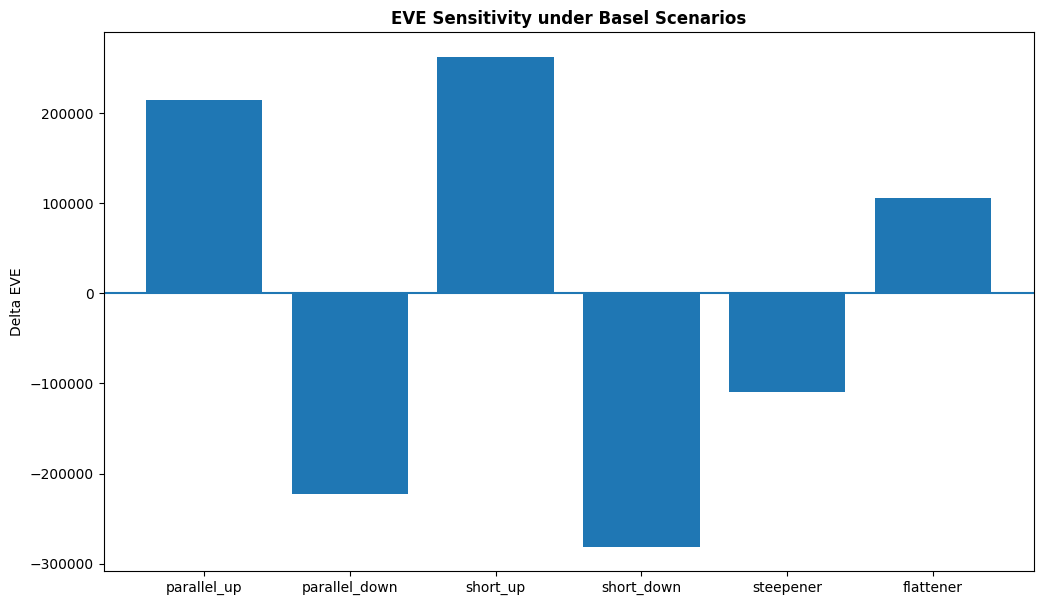

In [6]:
# plotting delta EVE under Basel shock scenarios
plt.figure(figsize=(12, 7))
plt.bar(
    results_df.index,
    results_df['Delta_EVE']
)
plt.axhline(0)
plt.title('EVE Sensitivity under Basel Scenarios', fontweight = 'bold')
plt.ylabel('Delta EVE')
plt.show()

This is an unrealistic EVE view, as we see that delta EVE rises in parallel_up scenario, which means that deposits durations are longer than asset durations without behavioral modelling, and deposit present values fall much more rapidly tahn loan present values -> counter-intuitive. Therefore, we need to introduce behavioral model for NMDs, that will definitely shorten the deposit duration, and flip EVE sign to match intuition.   